# Notebook 04: Omnibus permutation testing

For each metadata variable, we ask a single question: **does the full 5-component NMF embedding contain information about this variable, beyond what would be expected by chance?**

This is one test per variable rather than one test per (component × variable) pair, reducing the multiple-testing burden from 80 tests to 17 and using all components jointly as predictors.

## Procedure

For each metadata variable:
1. Fit an appropriate multivariate model relating the variable to all 5 components.
2. Compute an observed test statistic (R² for continuous, McFadden pseudo-R² for binary/multi).
3. Permute the metadata variable 5,000 times. Each time, refit the model and record the test statistic. This builds a null distribution.
4. The permutation p-value is the fraction of permuted statistics that meet or exceed the observed value.
5. Apply FDR correction (Benjamini-Hochberg) across the 17 resulting p-values.

**For variables surviving correction**, we then run an exploratory follow-up to identify which components contributed most.

**Inputs:**
- `outputs/nmf_W.csv`
- `outputs/metadata.csv`

**Outputs:**
- `outputs/omnibus_results.csv` — one row per variable
- `outputs/omnibus_null_distributions.png` — visual of observed vs. null distribution for each test
- `outputs/component_contributions.csv` — for any FDR-significant variable, which component contributed most

## Setup

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.preprocessing import StandardScaler
from statsmodels.stats.multitest import multipletests
import warnings
warnings.filterwarnings("ignore")

PROJECT_ROOT = Path(".").resolve().parent
OUTPUT_DIR = PROJECT_ROOT / "outputs"

N_PERMUTATIONS = 5000
FDR_ALPHA = 0.05
RANDOM_SEED = 42
rng = np.random.default_rng(RANDOM_SEED)

## Load data

In [2]:
W = pd.read_csv(OUTPUT_DIR / "nmf_W.csv", index_col="participant_id")
metadata = pd.read_csv(OUTPUT_DIR / "metadata.csv")
metadata = metadata.set_index("participant_id").reindex(W.index)
assert (W.index == metadata.index).all()

print(f"W shape:        {W.shape}")
print(f"Metadata shape: {metadata.shape}")
print(f"\nN permutations: {N_PERMUTATIONS}")

W shape:        (86, 5)
Metadata shape: (86, 17)

N permutations: 5000


## Variable classification

Same classification as Notebook 04 (per-component version). Editable if needed.

In [3]:
VAR_TYPES = {
    "Age":                                  "continuous",
    "Gender":                               "binary",
    "Residential Area (Urban/Rural)":       "binary",
    "From City":                            "binary",
    "Single/NotSingle":                     "binary",
    "Education":                            "multi",
    "Field of Study":                       "multi",
    "Occupation":                           "multi",
    "# of LanguagesSpeak":                  "continuous",
    "UsedToDoSport":                        "binary",
    "NowDoingSports_aWeek":                 "continuous",
    "PlayingAnInstrument":                  "binary",
    "History of Neurological Disorders":    "binary",
    "Medication Usage":                     "binary",
    "Average Sleep Hours per Night":        "continuous",
    "Smoking (0,1,2,3)":                    "continuous",
    "Alchocol (0,1,2,3)":                   "continuous",
}
VAR_TYPES = {v: t for v, t in VAR_TYPES.items() if v in metadata.columns}

## Helper functions

We need a function that computes the observed test statistic for a given (X, y) pair. The statistic differs by outcome type:

- **Continuous**: R² from linear regression
- **Binary**: McFadden pseudo-R² from logistic regression (1 - log-lik(full)/log-lik(null))
- **Multi-category**: McFadden pseudo-R² from multinomial logistic regression

In [4]:
def compute_statistic_continuous(X, y):
    """R² of linear regression of y on X."""
    model = LinearRegression().fit(X, y)
    return model.score(X, y)

def log_likelihood_logistic(model, X, y):
    proba = model.predict_proba(X)
    proba = np.clip(proba, 1e-12, 1 - 1e-12)
    if proba.shape[1] == 2:  # binary
        return np.sum(y * np.log(proba[:, 1]) + (1 - y) * np.log(proba[:, 0]))
    else:  # multi-class
        classes = model.classes_
        ll = 0.0
        for cls_idx, cls in enumerate(classes):
            mask = (y == cls)
            ll += np.sum(np.log(proba[mask, cls_idx]))
        return ll

def compute_statistic_classification(X, y):
    """McFadden pseudo-R²: 1 - log-lik(full) / log-lik(null).
    Higher is better. Range usually 0 to ~0.4 for good fits."""
    if len(np.unique(y)) < 2:
        return np.nan
    # Full model
    try:
        full = LogisticRegression(max_iter=2000, multi_class="auto", solver="lbfgs").fit(X, y)
        ll_full = log_likelihood_logistic(full, X, y)
    except Exception:
        return np.nan
    # Null model (intercept only): predict the class prior
    classes, counts = np.unique(y, return_counts=True)
    priors = counts / counts.sum()
    ll_null = sum(c * np.log(p) for c, p in zip(counts, priors))
    if ll_null == 0:
        return np.nan
    return 1 - (ll_full / ll_null)

def compute_statistic(X, y, vtype):
    if vtype == "continuous":
        return compute_statistic_continuous(X, y)
    elif vtype in ("binary", "multi"):
        return compute_statistic_classification(X, y)
    raise ValueError(f"Unknown vtype: {vtype}")

## Run omnibus permutation tests

This is the slowest cell — 17 variables × 5,000 permutations × model refit each time. Expect roughly 5-15 minutes depending on machine. The logistic regression refits are the bottleneck.

In [5]:
import time

# Standardize components for numerical stability
scaler = StandardScaler()
W_std = scaler.fit_transform(W.values)

results = []
null_distributions = {}

start = time.time()
for var, vtype in VAR_TYPES.items():
    sub = pd.DataFrame({"y": metadata[var]})
    sub["idx"] = np.arange(len(sub))
    sub = sub.dropna()
    if len(sub) < 10:
        results.append({"variable": var, "type": vtype, "n": len(sub),
                        "observed_stat": np.nan, "p_perm": np.nan,
                        "note": "insufficient n"})
        continue

    indices = sub["idx"].values
    X_use = W_std[indices]
    y_use = sub["y"].values

    # Encode categorical y to integers
    if vtype != "continuous":
        y_encoded, _ = pd.factorize(y_use)
        y_use_arr = y_encoded
    else:
        y_use_arr = pd.to_numeric(y_use, errors="coerce")
        valid = ~pd.isna(y_use_arr)
        if valid.sum() < 10:
            results.append({"variable": var, "type": vtype, "n": int(valid.sum()),
                            "observed_stat": np.nan, "p_perm": np.nan,
                            "note": "insufficient numeric data"})
            continue
        X_use = X_use[valid]
        y_use_arr = y_use_arr[valid].astype(float)

    # Observed statistic
    t_var = time.time()
    obs_stat = compute_statistic(X_use, y_use_arr, vtype)
    if np.isnan(obs_stat):
        results.append({"variable": var, "type": vtype, "n": len(y_use_arr),
                        "observed_stat": np.nan, "p_perm": np.nan,
                        "note": "statistic failed"})
        continue

    # Permutation null distribution
    null_stats = np.zeros(N_PERMUTATIONS)
    y_perm = y_use_arr.copy()
    for i in range(N_PERMUTATIONS):
        rng.shuffle(y_perm)
        null_stats[i] = compute_statistic(X_use, y_perm, vtype)

    # Permutation p-value: fraction of null statistics >= observed
    # (+1 in numerator and denominator for unbiased estimator)
    p_perm = (np.sum(null_stats >= obs_stat) + 1) / (N_PERMUTATIONS + 1)

    null_distributions[var] = null_stats
    results.append({
        "variable": var, "type": vtype, "n": len(y_use_arr),
        "observed_stat": obs_stat,
        "null_mean": np.mean(null_stats),
        "null_95pct": np.percentile(null_stats, 95),
        "p_perm": p_perm,
        "note": "",
    })
    elapsed = time.time() - t_var
    print(f"{var:45s} | n={len(y_use_arr):3d} | obs={obs_stat:.4f} | null_mean={np.mean(null_stats):.4f} | "
          f"p={p_perm:.4f} | {elapsed:.1f}s")

print(f"\nTotal time: {time.time() - start:.1f}s")
omnibus_df = pd.DataFrame(results)

Age                                           | n= 86 | obs=0.0420 | null_mean=0.0588 | p=0.6201 | 5.3s
Gender                                        | n= 86 | obs=0.2742 | null_mean=0.0441 | p=0.0002 | 7.3s
Residential Area (Urban/Rural)                | n= 86 | obs=0.0881 | null_mean=0.0812 | p=0.3673 | 8.3s
From City                                     | n= 86 | obs=0.3308 | null_mean=0.2966 | p=0.1282 | 35.8s
Single/NotSingle                              | n= 86 | obs=0.0427 | null_mean=0.0556 | p=0.5747 | 8.5s
Education                                     | n= 86 | obs=0.1035 | null_mean=0.0771 | p=0.1644 | 14.0s
Field of Study                                | n= 85 | obs=0.2842 | null_mean=0.2804 | p=0.4305 | 37.8s
Occupation                                    | n= 86 | obs=0.2332 | null_mean=0.2498 | p=0.7574 | 30.3s
# of LanguagesSpeak                           | n= 86 | obs=0.0447 | null_mean=0.0577 | p=0.5771 | 4.0s
UsedToDoSport                                 | n= 86 | obs=

## Multiple-testing correction

In [6]:
valid_mask = omnibus_df["p_perm"].notna()
p_valid = omnibus_df.loc[valid_mask, "p_perm"].values

if len(p_valid) > 0:
    reject, p_fdr, _, _ = multipletests(p_valid, alpha=FDR_ALPHA, method="fdr_bh")
    omnibus_df.loc[valid_mask, "p_fdr"] = p_fdr
    omnibus_df.loc[valid_mask, "significant_fdr"] = reject
else:
    omnibus_df["p_fdr"] = np.nan
    omnibus_df["significant_fdr"] = False

omnibus_df["significant_fdr"] = omnibus_df["significant_fdr"].fillna(False)
omnibus_df = omnibus_df.sort_values("p_perm")
omnibus_df.to_csv(OUTPUT_DIR / "omnibus_results.csv", index=False)

print("Omnibus permutation results (sorted by p_perm):")
display_cols = ["variable", "type", "n", "observed_stat", "null_mean", "p_perm", "p_fdr", "significant_fdr"]
print(omnibus_df[display_cols].round(4).to_string(index=False))

n_nominal = (omnibus_df["p_perm"] < 0.05).sum()
n_fdr = omnibus_df["significant_fdr"].sum()
print(f"\n{n_nominal} variables with nominal p < 0.05")
print(f"{n_fdr} variables significant after FDR correction")

Omnibus permutation results (sorted by p_perm):
                         variable       type  n  observed_stat  null_mean  p_perm  p_fdr  significant_fdr
                           Gender     binary 86         0.2742     0.0441  0.0002 0.0034             True
                        From City     binary 86         0.3308     0.2966  0.1282 0.6986            False
                 Medication Usage     binary 86         0.2175     0.1356  0.1528 0.6986            False
                        Education      multi 86         0.1035     0.0771  0.1644 0.6986            False
              PlayingAnInstrument     binary 86         0.0608     0.0540  0.3425 0.8510            False
   Residential Area (Urban/Rural)     binary 86         0.0881     0.0812  0.3673 0.8510            False
                    UsedToDoSport     binary 86         0.0540     0.0535  0.4069 0.8510            False
                   Field of Study      multi 85         0.2842     0.2804  0.4305 0.8510            Fals

## Visualize null distributions

For each variable, show the null distribution of the test statistic with the observed value overlaid as a red line. Lets you see whether the observed value is comfortably in the tail or sits near the middle of the null.

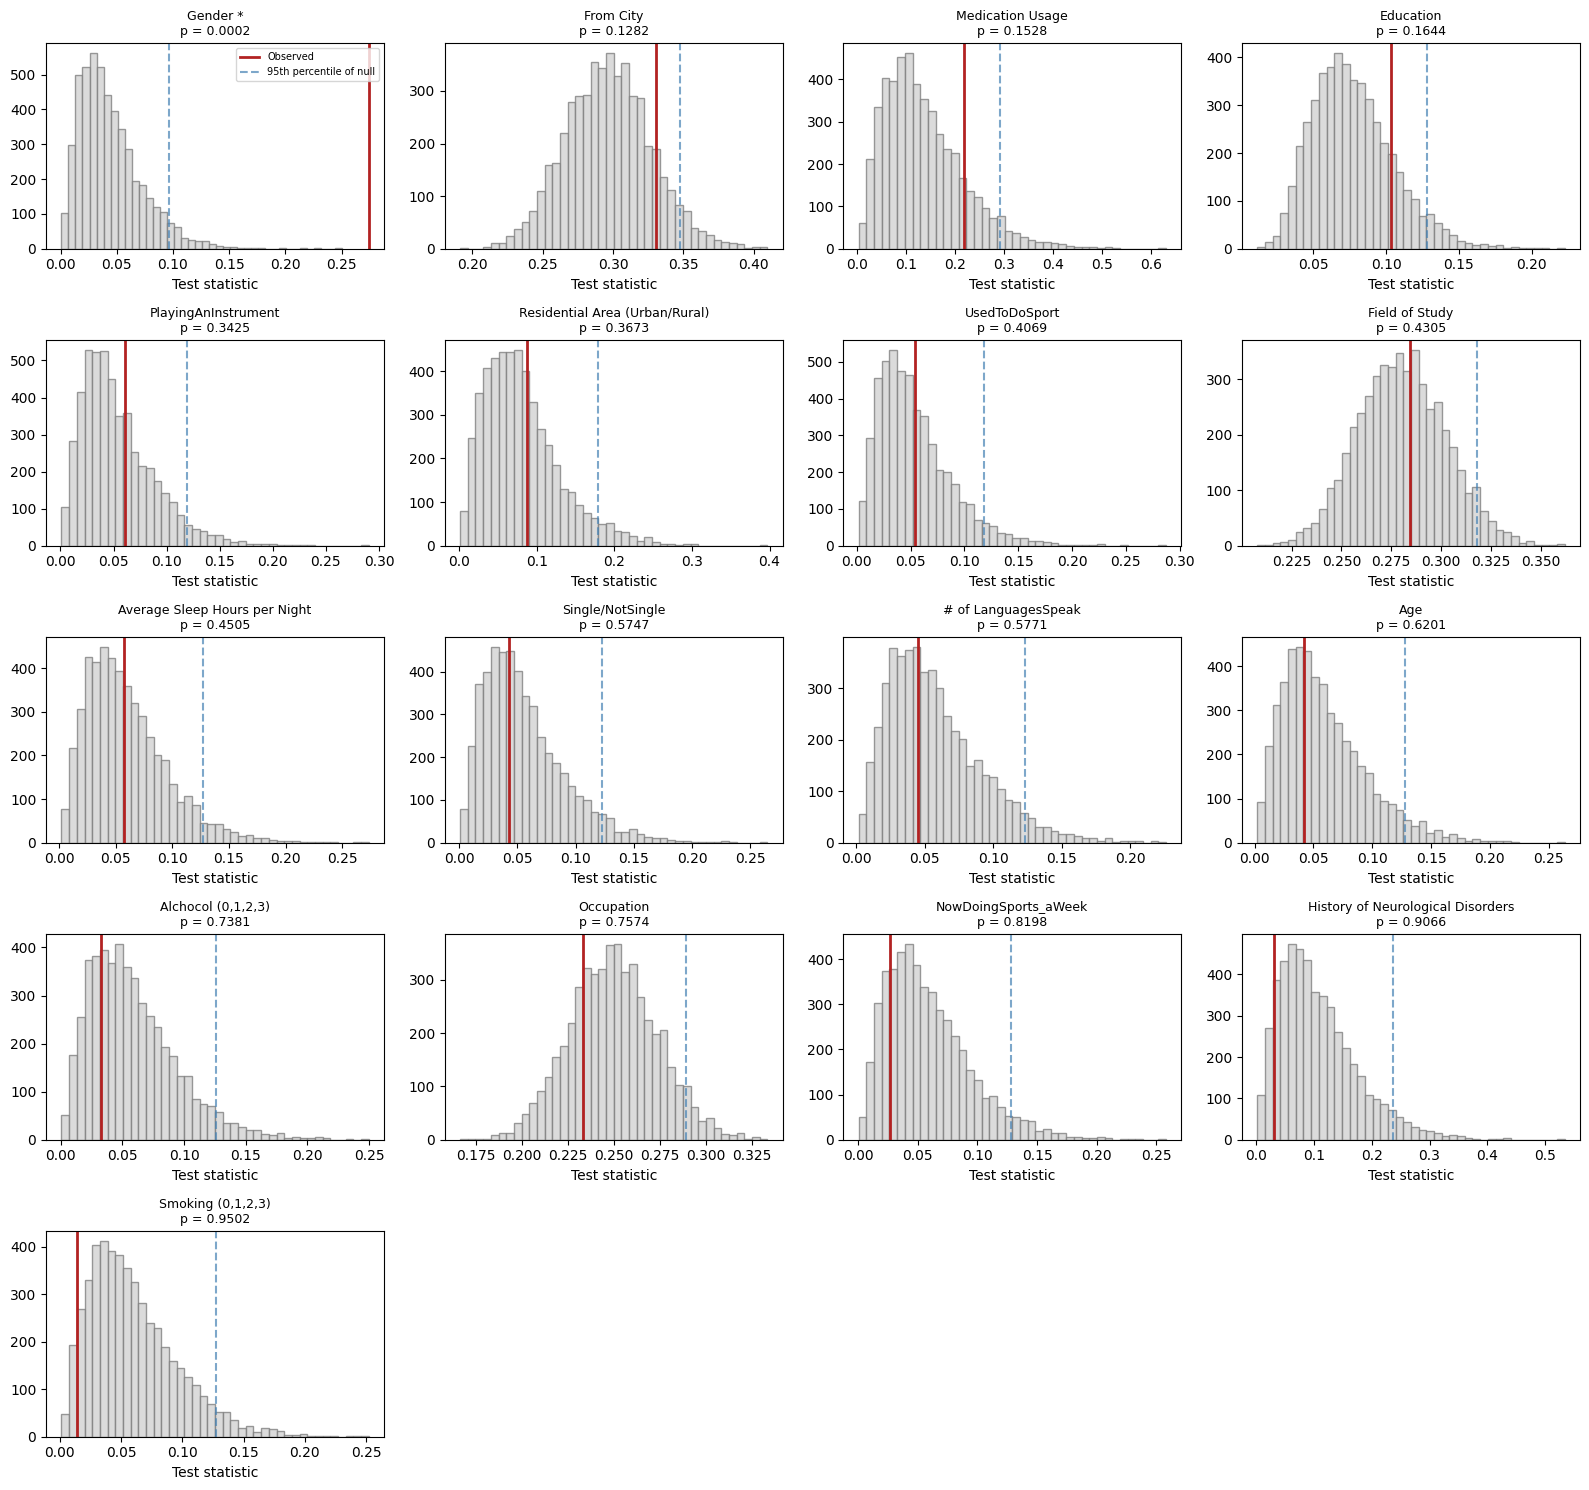

In [7]:
vars_to_plot = omnibus_df.dropna(subset=["observed_stat"]).sort_values("p_perm")["variable"].tolist()
n_plots = len(vars_to_plot)
n_cols = 4
n_rows = (n_plots + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 3 * n_rows))
axes = axes.flatten()

for idx, var in enumerate(vars_to_plot):
    ax = axes[idx]
    null_stats = null_distributions[var]
    obs = omnibus_df.loc[omnibus_df["variable"] == var, "observed_stat"].values[0]
    p_perm = omnibus_df.loc[omnibus_df["variable"] == var, "p_perm"].values[0]
    sig = omnibus_df.loc[omnibus_df["variable"] == var, "significant_fdr"].values[0]

    ax.hist(null_stats, bins=40, color="lightgray", edgecolor="gray", alpha=0.8)
    ax.axvline(obs, color="firebrick", linewidth=2, label=f"Observed")
    ax.axvline(np.percentile(null_stats, 95), color="steelblue",
               linestyle="--", alpha=0.7, label="95th percentile of null")
    title = var[:40]
    if sig:
        title += " *"
    ax.set_title(f"{title}\np = {p_perm:.4f}", fontsize=9)
    ax.set_xlabel("Test statistic")
    if idx == 0:
        ax.legend(fontsize=7, loc="upper right")

for j in range(n_plots, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "omnibus_null_distributions.png", dpi=150, bbox_inches="tight")
plt.show()

## Follow-up: component contributions for FDR-significant variables

For any variable that survived FDR correction, identify which component(s) drove the omnibus result. We report regression coefficients (for continuous outcomes) or class-conditional component means (for categorical) as exploratory descriptive findings.

**Important**: these are exploratory and not independently corrected. They serve to localize the omnibus signal, not to make new significance claims.

In [8]:
sig_vars = omnibus_df[omnibus_df["significant_fdr"]]["variable"].tolist()

if len(sig_vars) == 0:
    print("No variables survived FDR correction. No follow-up needed.")
    contributions_df = pd.DataFrame()
else:
    contribution_rows = []
    for var in sig_vars:
        vtype = VAR_TYPES[var]
        sub = pd.DataFrame({"y": metadata[var]}).dropna()
        indices = sub.index.map(lambda p: W.index.get_loc(p)).tolist()
        X_use = W_std[indices]
        y_use = sub["y"].values

        if vtype == "continuous":
            y_num = pd.to_numeric(y_use, errors="coerce")
            valid = ~pd.isna(y_num)
            model = LinearRegression().fit(X_use[valid], y_num[valid])
            for comp_idx, comp_name in enumerate(W.columns):
                contribution_rows.append({
                    "variable": var, "type": vtype, "component": comp_name,
                    "contribution_metric": "standardized_coef",
                    "value": model.coef_[comp_idx],
                })
        else:
            y_encoded, classes = pd.factorize(y_use)
            try:
                model = LogisticRegression(max_iter=2000, multi_class="auto", solver="lbfgs").fit(X_use, y_encoded)
                # For binary, model.coef_ shape is (1, 5); for multi, (n_classes, 5)
                # Report mean absolute coefficient across classes per component
                coef_summary = np.abs(model.coef_).mean(axis=0)
                for comp_idx, comp_name in enumerate(W.columns):
                    contribution_rows.append({
                        "variable": var, "type": vtype, "component": comp_name,
                        "contribution_metric": "mean_abs_coef",
                        "value": coef_summary[comp_idx],
                    })
            except Exception:
                pass

    contributions_df = pd.DataFrame(contribution_rows)
    contributions_df.to_csv(OUTPUT_DIR / "component_contributions.csv", index=False)
    print("Component contributions for FDR-significant variables:")
    for var in sig_vars:
        sub = contributions_df[contributions_df["variable"] == var]
        sub = sub.reindex(sub["value"].abs().sort_values(ascending=False).index)
        print(f"\n{var}:")
        print(sub[["component", "contribution_metric", "value"]].round(4).to_string(index=False))

Component contributions for FDR-significant variables:

Gender:
component contribution_metric  value
   comp_1       mean_abs_coef 1.3823
   comp_4       mean_abs_coef 0.5988
   comp_2       mean_abs_coef 0.3741
   comp_5       mean_abs_coef 0.1903
   comp_3       mean_abs_coef 0.1641


## Summary

In [9]:
print("=" * 60)
print("OMNIBUS PERMUTATION TEST SUMMARY")
print("=" * 60)
print(f"\nN participants:     {len(W)}")
print(f"N components:       {len(W.columns)}")
print(f"N variables tested: {valid_mask.sum()}")
print(f"N permutations:     {N_PERMUTATIONS}")
print(f"FDR threshold:      {FDR_ALPHA}")
print()
print(f"Results:")
print(f"  Nominally significant (p_perm < 0.05): {(omnibus_df['p_perm'] < 0.05).sum()}")
print(f"  FDR-significant (BH at alpha={FDR_ALPHA}):  {omnibus_df['significant_fdr'].sum()}")

if omnibus_df['significant_fdr'].sum() > 0:
    print("\nFDR-significant variables:")
    for _, row in omnibus_df[omnibus_df['significant_fdr']].iterrows():
        print(f"  {row['variable']:40s} | {row['type']:10s} | stat={row['observed_stat']:6.3f} | p_fdr={row['p_fdr']:.4f}")
else:
    print("\nNo variables survived FDR correction.")
    print("\nTop 5 by uncorrected p-value (for context):")
    top5 = omnibus_df.dropna(subset=["p_perm"]).nsmallest(5, "p_perm")
    for _, row in top5.iterrows():
        print(f"  {row['variable']:40s} | stat={row['observed_stat']:6.3f} | p_perm={row['p_perm']:.4f}")

print("\nFiles saved:")
print("  omnibus_results.csv")
print("  omnibus_null_distributions.png")
print("  component_contributions.csv (if any significant)")

OMNIBUS PERMUTATION TEST SUMMARY

N participants:     86
N components:       5
N variables tested: 17
N permutations:     5000
FDR threshold:      0.05

Results:
  Nominally significant (p_perm < 0.05): 1
  FDR-significant (BH at alpha=0.05):  1

FDR-significant variables:
  Gender                                   | binary     | stat= 0.274 | p_fdr=0.0034

Files saved:
  omnibus_results.csv
  omnibus_null_distributions.png
  component_contributions.csv (if any significant)
